Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [10]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [11]:
checkpoint_dir  =  Path("../checkpoints/rtpp_20251215-151407") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/nhpp_20251208-165235") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [12]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: _IncompatibleKeys(missing_keys=['bg_model.mlp.fc.1.weight', 'bg_model.mlp.fc.1.bias', 'bg_model.mlp.fc.4.weight', 'bg_model.mlp.fc.4.bias', 'bg_model.mlp.fc.5.weight', 'bg_model.mlp.fc.5.bias', 'bg_model.mlp.fc.8.weight', 'bg_model.mlp.fc.8.bias'], unexpected_keys=['bg_model.mlp.fc.3.weight', 'bg_model.mlp.fc.3.bias', 'bg_model.mlp.fc.6.weight', 'bg_model.mlp.fc.6.bias'])
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'conv_mlp', 'bg_model_cfg': {'d_feature': 1, 'scale_init': 200.0}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'scale_range': 'decay', 'dim'

In [13]:
# model.bg_model = model2.bg_model

In [14]:
model.bg_model._scale

tensor(143.5848, device='cuda:0', grad_fn=<ExpBackward0>)

## Loading the catalog

In [15]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [16]:
catalog_ds.full_sequence

Sequence(
  inter_times: [6141],
  arrival_times: [6140],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [6140],
  loc: [6140, 2],
  depth: [6140],
  time_series: [92376, 1],
  time_series_times: [92376]
)

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

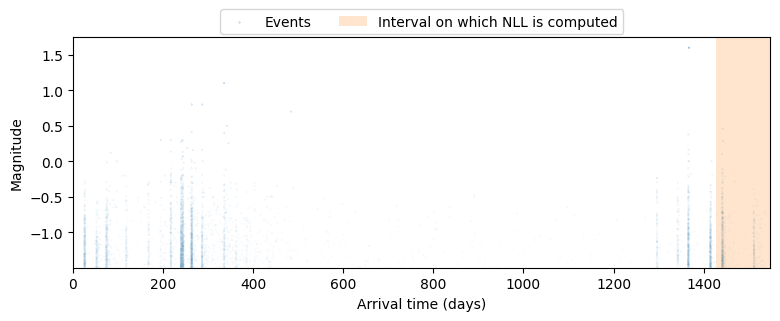

In [17]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [18]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 4087],
  arrival_times: [1, 4087],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 4087],
  input_mask: [1, 4087],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 4087],
  type_seq: [1, 4087],
  mag: [1, 4087],
  loc: [1, 4087, 2],
  depth: [1, 4087],
  time_series: [1, 54001, 1],
  time_series_times: [1, 54001]
)

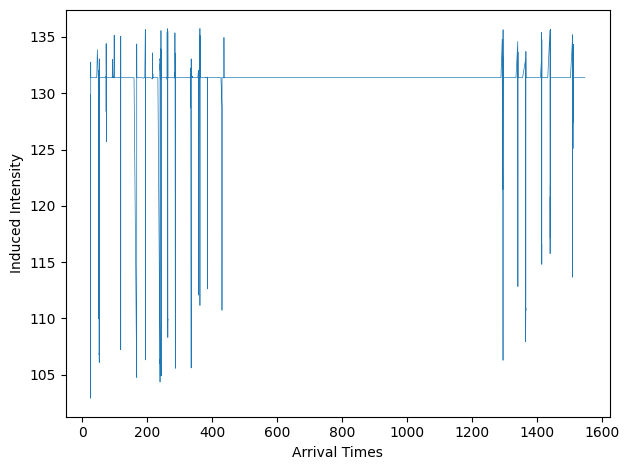

In [19]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
    f_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Induced Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'induced_intensity.png')

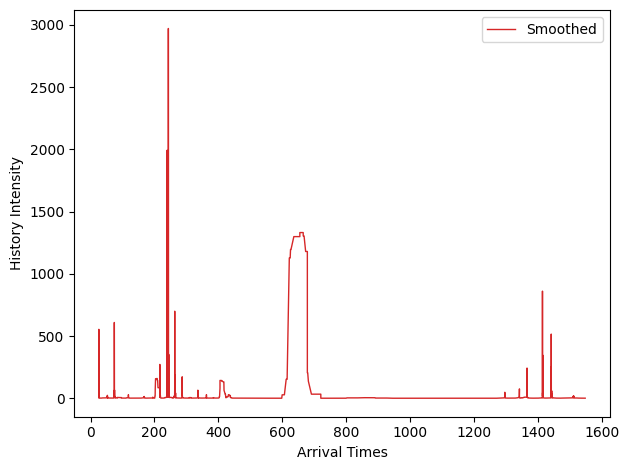

In [20]:
context = model.get_context(test_batch)
inter_time_dist = model.get_inter_time_dist(context)
log_h_intensity = inter_time_dist.log_hazard(test_batch.inter_times.clamp_min(1e-10))
h_intensity = torch.exp(log_h_intensity)
h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

window = 20  # smoothing window size
arrival_times_np = test_batch.arrival_times.detach().cpu().numpy().ravel()
raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

plt.xlabel('Arrival Times')
plt.ylabel('History Intensity')
# plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
plt.legend()
plt.tight_layout()

In [21]:
(h_intensity > 1000).sum().item()

65

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [22]:
t_forecast = 1430 # 1460
duration = 60 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast,reset_t_nll_to_end=True) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration,reset_t_nll_to_end=True)

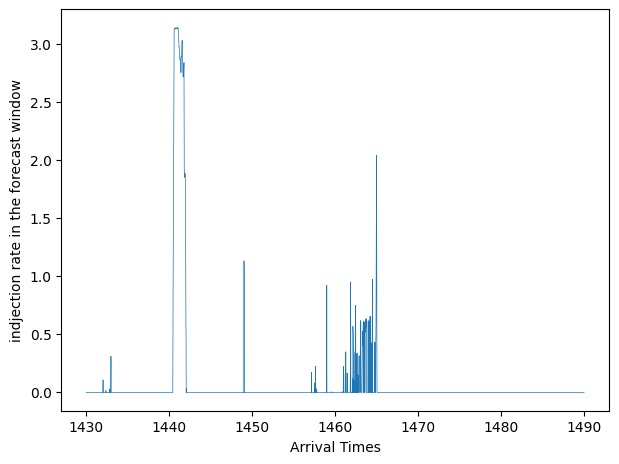

In [23]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [24]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [25]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

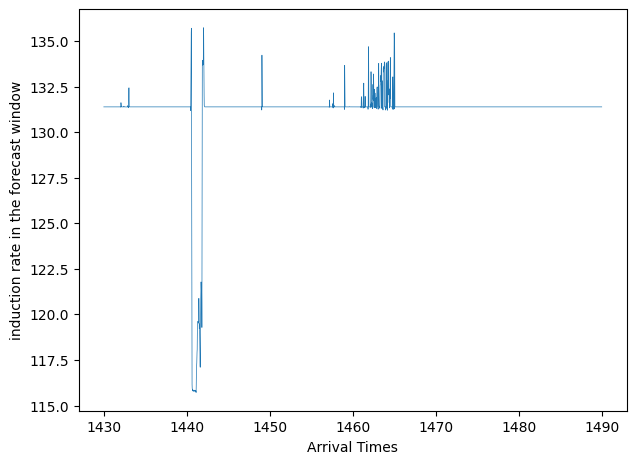

In [26]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
model.bg_model.ts_batch_cache
times_all = test_seq.time_series_times
mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
plt.xlabel('Arrival Times')
plt.ylabel('induction rate in the forecast window')
plt.tight_layout()
plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

599

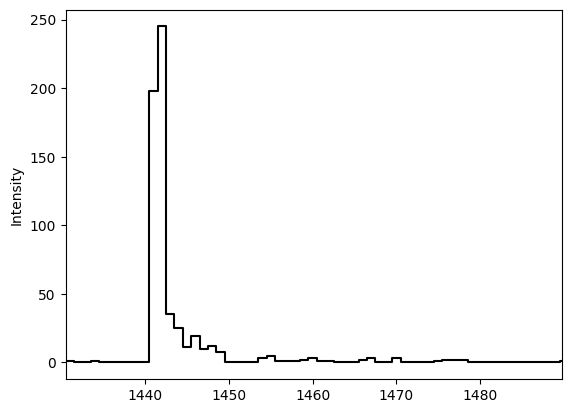

In [27]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1)
len(observed_seq)

In [28]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [29]:
model.nll_loss(train_batch)

f_intensity max:     135.75567626953125, h_intensity max: 53180.58984375
nll_bg mean: 88811.9140625, nll_total mean: 83261.171875


tensor([[111.9102]], device='cuda:0', grad_fn=<DivBackward0>)

In [ ]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode
all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

In [ ]:
all_forecasts

[Sequence(
   inter_times: [440],
   arrival_times: [439],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [439]
 ),
 Sequence(
   inter_times: [432],
   arrival_times: [431],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [431]
 ),
 Sequence(
   inter_times: [461],
   arrival_times: [460],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [460]
 ),
 Sequence(
   inter_times: [438],
   arrival_times: [437],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [437]
 ),
 Sequence(
   inter_times: [456],
   arrival_times: [455],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [455]
 ),
 Sequence(
   inter_times: [479],
   arrival_times: [478],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [478]
 ),
 Sequence(
   inter_times: [425],
   arrival_times: [424],
   t_start: 1430.0,
   t_end: 1490.0,
   t_nll_start: 1430.0,
   mag: [424]
 ),
 Sequence(
   inter_times: 

In [ ]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [38, 52, 55, 59, 102, 124, 167, 176, 193, 215, 339, 340, 358, 370, 402, 413, 438, 455, 456, 457, 468, 487, 512, 513, 518, 526, 561, 572, 582, 591, 595, 623, 630, 634, 646, 697, 748, 749, 760, 767, 804, 818, 848, 865, 873, 921, 925, 948, 969, 995, 1028, 1030, 1058, 1071, 1088, 1105, 1126, 1168, 1222, 1264, 1299, 1314, 1342, 1353, 1355, 1371, 1387, 1403, 1427, 1454, 1464, 1470, 1477, 1484, 1494, 1518, 1522, 1532, 1546, 1578, 1651, 1696, 1709, 1729, 1735, 1784, 1797, 1822, 1876, 1892, 1914, 1918, 1953, 1967, 1982, 1983, 1994, 2004, 2021, 2061, 2092, 2112, 2178, 2182, 2193, 2211, 2223, 2235, 2286, 2294, 2304, 2327, 2338, 2397, 2469, 2479, 2483, 2503, 2505, 2563, 2627, 2635, 2658, 2677, 2694, 2701, 2720, 2725, 2774, 2777, 2778, 2827, 2840, 2844, 2920, 2980, 3001, 3008, 3063, 3065, 3095, 3106, 3133, 3145, 3154, 3188, 3194, 3208, 3230, 3269, 3279, 3286, 3288, 3303, 3310, 3343, 3366, 3385, 3418, 3440, 3462, 3464, 3468, 3503, 3516, 3540, 3567, 3579, 3585, 

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [ ]:
model.bg_model.forecast_count(t_forecast, t_forecast + duration)
# model.bg_model.forecast_count(t_forecast+5, t_forecast + 10)

tensor(328.4817, device='cuda:0')

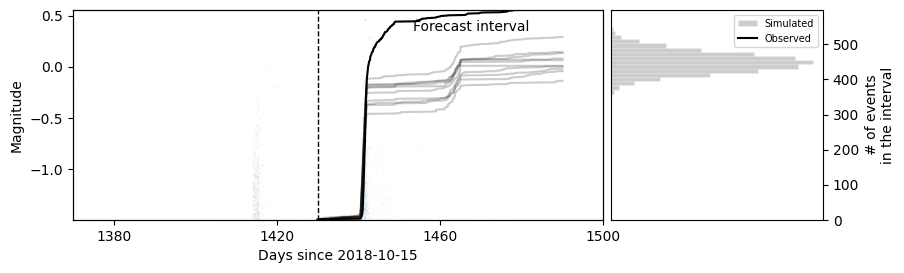

In [ ]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str,reset_t_nll_to_end=True)

In [ ]:
import  src.utils.catalog_tests as catalog_tests

In [ ]:
test_seq

Sequence(
  inter_times: [6141],
  arrival_times: [6140],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [6140],
  loc: [6140, 2],
  depth: [6140],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

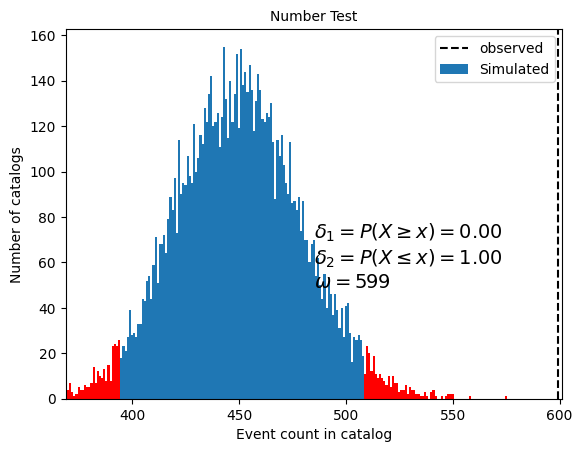

In [ ]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [ ]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [ ]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:423: SyntaxWarning: invalid escape sequence '\l'
  ylabel = plot_args.get('ylabel', '$P(X \leq x)$')
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1106: SyntaxWarning: invalid escape sequence '\d'
  '$\delta_1 = P(X \geq x) = {:.2f}$\n$\delta_2 = P(X \leq x) = {:.2f}$\n$\omega = {:d}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1113: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \leq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1205: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1213: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1281: Syntax

IndexError: index -1 is out of bounds for axis 0 with size 0

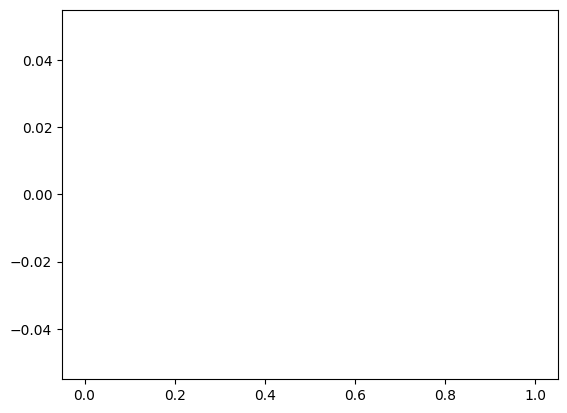

In [ ]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')